In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import os
import re
import itertools


def get_loc_train_fmt(fname):
    # 0209-[LOC]_[ID].jpg
    return re.split(r'[-_.]', fname)[1]

def get_loc_test_fmt(fname):
    # [LOC]_[ID].jpg
    return fname.split('_')[0]


def get_fnames_common_pool(root, loc, get_loc):
    return tuple(
        map(lambda x: f"{root}/{x}",
        filter(lambda x: loc == get_loc(x),
        os.listdir(root)
    )))


def mean_img(fnames):
    imgs_sum = None
    for fname in fnames:
            img: np.ndarray = cv2.imread(fname)  # type: ignore
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if imgs_sum is None:
                imgs_sum = np.zeros_like(img, dtype=np.float64)
            imgs_sum += img

    res = imgs_sum / len(fnames)  # type: ignore
    res = res.astype(np.uint8)
    return res

def var_img(fnames, mean=None):
    mean = mean or mean_img(fnames)
    imgs_acc = None
    for fname in fnames:
        img: np.ndarray = cv2.imread(fname)  # type: ignore
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if imgs_acc is None:
            imgs_acc = np.zeros_like(img, dtype=np.float64)
        imgs_acc += (img - mean)**2
    res = imgs_acc / len(fnames)  # type: ignore
    return res

def std_img(fnames, mean=None):
    return np.sqrt(var_img(fnames, mean))

def std_img_rgb(fnames, mean=None):
    std = std_img(fnames, mean)
    res = std / std.max() * 256
    res = res.astype(np.uint8)
    return res

In [2]:
TRN_LOC = set()
TRN_PTH = "./dl-lab-2-stuff-detection/yolo_dataset/yolo_dataset/train/images"
TST_LOC = set()
TST_PTH = "./dl-lab-2-stuff-detection/test_images/test_images"

for fname in tqdm(os.listdir(TRN_PTH), desc="TRN"):
    TRN_LOC.add(get_loc_train_fmt(fname))
TRN_LOC = frozenset(TRN_LOC)

for fname in tqdm(os.listdir(TST_PTH), desc="TST"):
    TST_LOC.add(get_loc_test_fmt(fname))
TST_LOC = frozenset(TST_LOC)

print(f"{TRN_LOC=}")
print(f"{TST_LOC=}")

TST: 100%|██████████| 4454/4454 [00:00<00:00, 657542.15it/s]

TRN_LOC=frozenset({'13', '30', '33', '31', '15', '24', '14', '8', '26', '2', '17', '20', '6', '10', '18', '21', '5', '3', '28', '27', '35', '19', '29', '23', '22', '16', '25', '34', '11', '7', '12'})
TST_LOC=frozenset({'19.1', '14.1', '1.1', '16.1', '13.1', '3', '21', '35', '32', '15.1', '3.1', '37', '14', '8', '10.1'})


In [15]:
OUT_DIR = "./mean_images"

for loc in tqdm(TRN_LOC, desc='TRN'):
    mean = mean_img(get_fnames_common_pool(TRN_PTH, loc, get_loc_train_fmt))
    out = f"{OUT_DIR}/trn-{loc}.jpg"
    cv2.imwrite(out, mean)

for loc in tqdm(TST_LOC, desc='TST'):
    mean = mean_img(get_fnames_common_pool(TST_PTH, loc, get_loc_test_fmt))
    out = f"{OUT_DIR}/tst-{loc}.jpg"
    cv2.imwrite(out, mean)

TST: 100%|██████████| 15/15 [00:30<00:00,  2.05s/it]


In [16]:
OUT_DIR = "./std_images"

for loc in tqdm(TRN_LOC, desc='TRN'):
    std = std_img_rgb(get_fnames_common_pool(TRN_PTH, loc, get_loc_train_fmt))
    out = f"{OUT_DIR}/trn-{loc}.jpg"
    cv2.imwrite(out, std)

for loc in tqdm(TST_LOC, desc='TST'):
    std = std_img_rgb(get_fnames_common_pool(TST_PTH, loc, get_loc_test_fmt))
    out = f"{OUT_DIR}/tst-{loc}.jpg"
    cv2.imwrite(out, std)

TST: 100%|██████████| 15/15 [01:01<00:00,  4.10s/it]


In [17]:
MEAN_DIR = "./mean_images"
print({
    cv2.imread(f"{MEAN_DIR}/{fname}").shape  # type: ignore
    for fname in tqdm(os.listdir(MEAN_DIR))
})

100%|██████████| 46/46 [00:00<00:00, 187.08it/s]

{(720, 1280, 3)}


100%|██████████| 465/465 [00:04<00:00, 93.62it/s] 


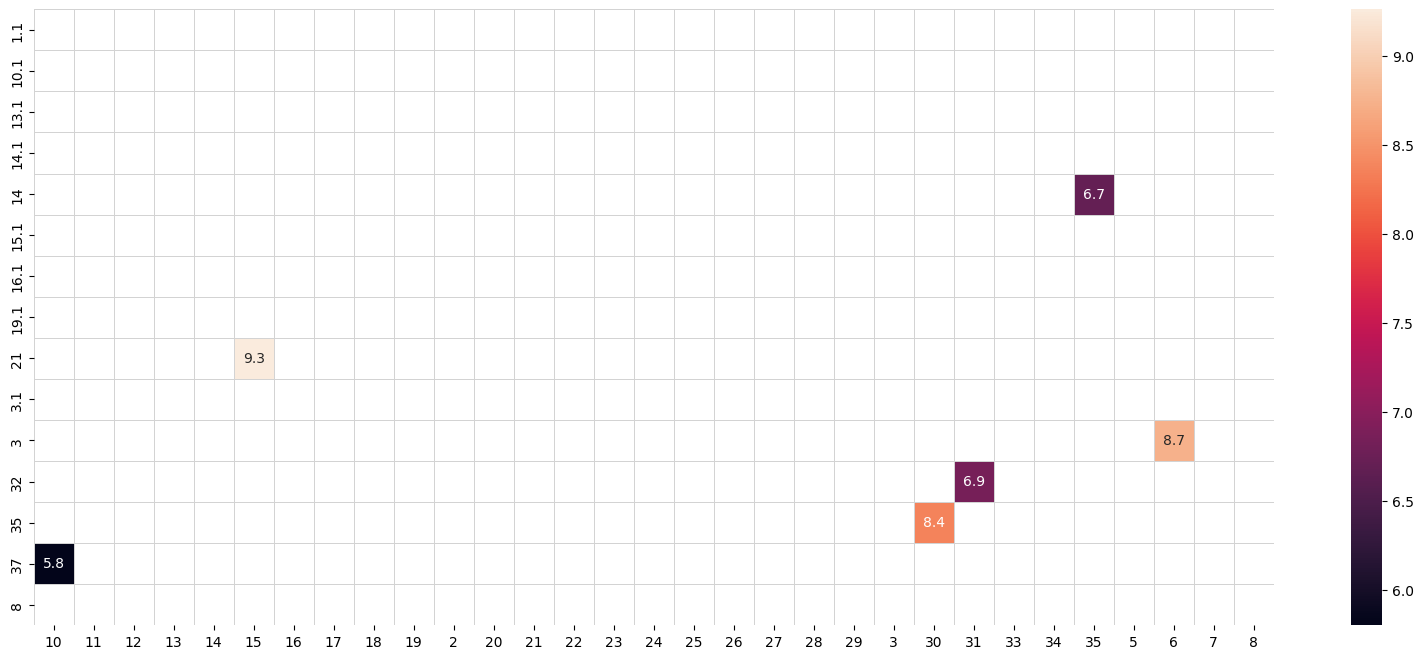

In [26]:
MEAN_DIR = "./mean_images"
_tsts = sorted(filter(lambda x: x.startswith('tst-'), os.listdir(MEAN_DIR)))
_trns = sorted(filter(lambda x: x.startswith('trn-'), os.listdir(MEAN_DIR)))
_n_tst, _n_trn = len(_tsts), len(_trns)
_matrix = np.zeros((_n_tst, _n_trn), dtype=np.float64)

for i1, i2 in tqdm(itertools.product(range(_n_tst), range(_n_trn)), total=_n_tst*_n_trn):
    img1: np.ndarray = cv2.imread(f"{MEAN_DIR}/{_tsts[i1]}")  # type: ignore
    img2: np.ndarray = cv2.imread(f"{MEAN_DIR}/{_trns[i2]}")  # type: ignore
    diff = (img1 - img2)**2
    diff_sum = np.sqrt(diff.sum() / 720 / 1280 / 3)
    _matrix[i1, i2] = diff_sum


_tst_lbls = tuple(map(lambda x: x.split('-')[1][:-4], _tsts))
_trn_lbls = tuple(map(lambda x: x.split('-')[1][:-4], _trns))

plt.figure(figsize=(20, 8))
sns.heatmap(_matrix, annot=True, fmt='.1f',
            mask=(_matrix > 9.5),
            linewidths=0.5, linecolor='lightgray',
            xticklabels=_trn_lbls, yticklabels=_tst_lbls)
plt.show()

In [3]:
OUT_DIR = "./mean_images"

_trn_weight = {
    loc: len(get_fnames_common_pool(TRN_PTH, loc, get_loc_train_fmt))
    for loc in tqdm(TRN_LOC, desc='TRN')}
_tst_weight = {
    loc: len(get_fnames_common_pool(TST_PTH, loc, get_loc_test_fmt))
    for loc in tqdm(TST_LOC, desc='TST')}



TST: 100%|██████████| 15/15 [00:00<00:00, 418.15it/s]


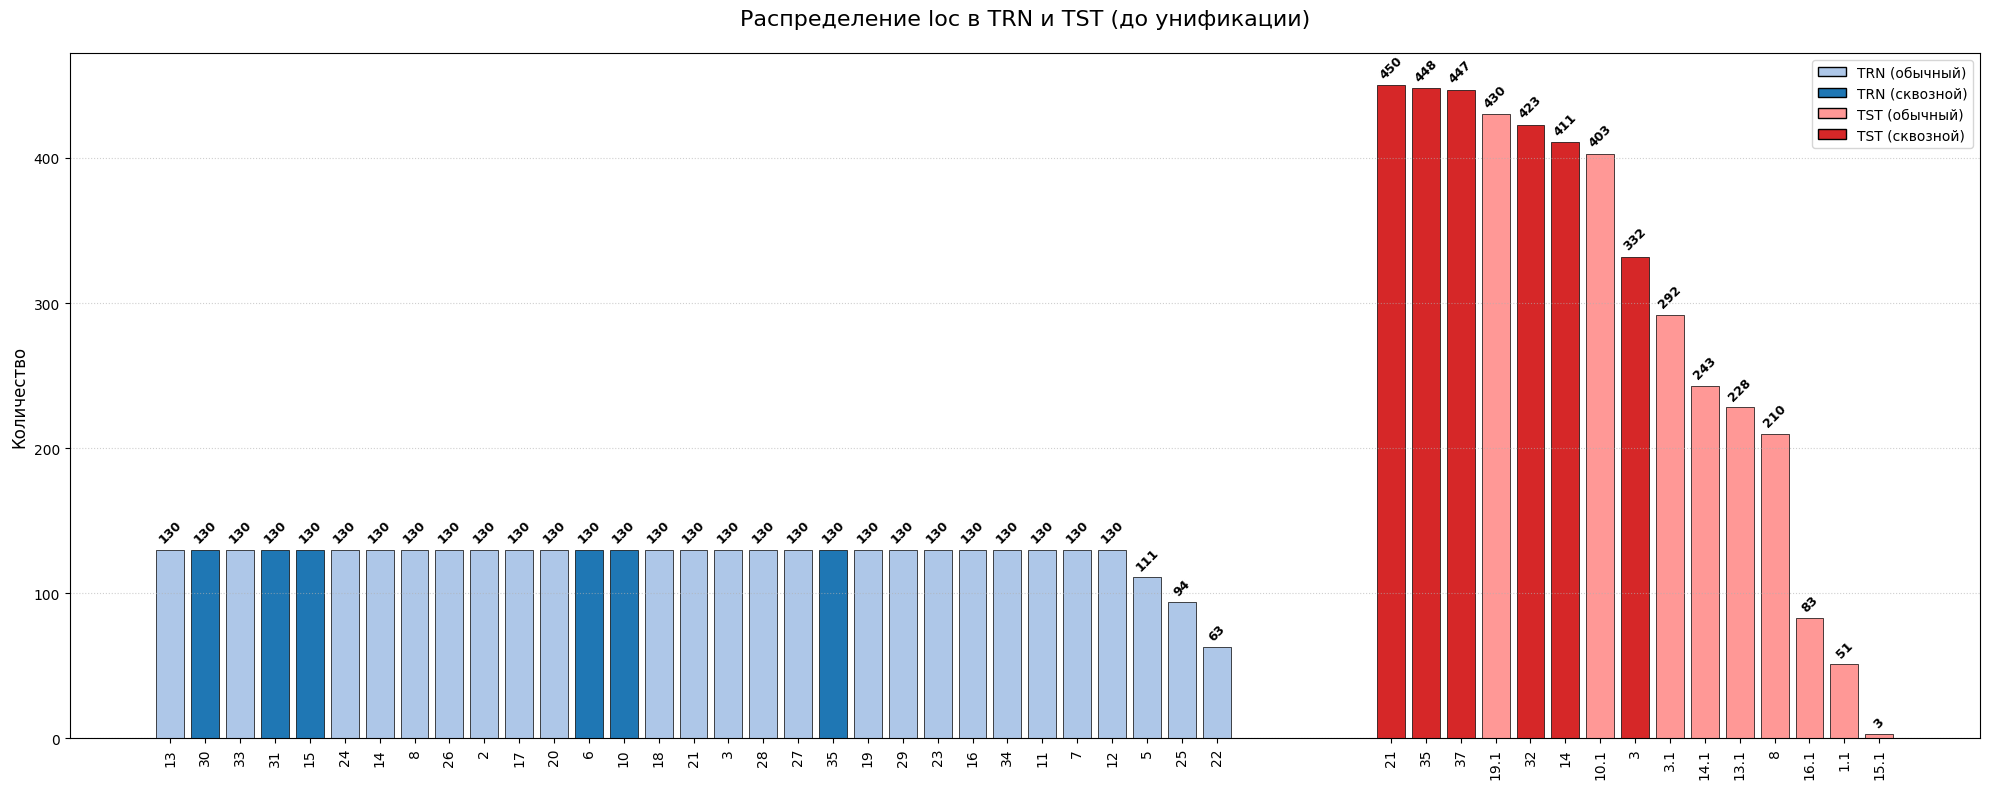

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Данные
trn_data = _trn_weight
tst_data = _tst_weight

# Список пар (для выделения)
links = [('14', '35'), ('21', '15'), ('3', '6'), ('32', '31'), ('35', '30'), ('37', '10')]
paired_tst = {pair[0] for pair in links}
paired_trn = {pair[1] for pair in links}

# Сортировка по значению
trn_keys = sorted(trn_data.keys(), key=lambda x: trn_data[x], reverse=True)
tst_keys = sorted(tst_data.keys(), key=lambda x: tst_data[x], reverse=True)

# 2. Определение цветов
trn_colors = ['#1f77b4' if k in paired_trn else '#aec7e8' for k in trn_keys]
tst_colors = ['#d62728' if k in paired_tst else '#ff9896' for k in tst_keys]

# 3. Позиции на оси X
gap = 4
trn_x = np.arange(len(trn_keys))
tst_x = np.arange(len(trn_keys) + gap, len(trn_keys) + gap + len(tst_keys))
all_x = np.concatenate([trn_x, tst_x])
all_keys = trn_keys + tst_keys

# 4. Визуализация
fig, ax = plt.subplots(figsize=(20, 8))

# Рисуем бары
bar_trn = ax.bar(trn_x, [trn_data[k] for k in trn_keys], color=trn_colors, edgecolor='black', linewidth=0.5)
bar_tst = ax.bar(tst_x, [tst_data[k] for k in tst_keys], color=tst_colors, edgecolor='black', linewidth=0.5)

# Добавляем текст над барами
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=45)

add_labels(bar_trn)
add_labels(bar_tst)

# Оформление осей
ax.set_xticks(all_x)
ax.set_xticklabels(all_keys, rotation=90, fontsize=10)
ax.set_title('Распределение loc в TRN и TST (до унификации)', fontsize=16, pad=20)
ax.set_ylabel('Количество', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#aec7e8', edgecolor='black', label='TRN (обычный)'),
    Patch(facecolor='#1f77b4', edgecolor='black', label='TRN (сквозной)'),
    Patch(facecolor='#ff9896', edgecolor='black', label='TST (обычный)'),
    Patch(facecolor='#d62728', edgecolor='black', label='TST (сквозной)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Итоги:
Идеи:
- 9 этих самых
- 6 сковзных локаций
- Серая жилетка
- Динамика вместо статики (сборка темпорального ансмбля)
  - трекинг
  - темпоральный анализ